In [43]:
#importaciones
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from scipy.signal import welch
from scipy.stats import skew, kurtosis

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import cross_val_score
from scipy.stats import randint


In [44]:
dataset = load_dataset("YominE/Muscle_Fatigue_Cycling")
dataset

DatasetDict({
    train: Dataset({
        features: ['Time', 'Right Rectus femoris', 'Left Gluteus maximus', 'Left Gastrocnemius medialis', 'Left Semitendinosus', 'Left Biceps femoris caput longus', 'Right Vastus medialis', 'Right Tibialis anterior', 'Left Gastrocnemius lateralis', 'Target'],
        num_rows: 3002137
    })
})

In [45]:

df = dataset["train"].to_pandas()
df.head()

,Time,Right Rectus femoris,Left Gluteus maximus,Left Gastrocnemius medialis,Left Semitendinosus,Left Biceps femoris caput longus,Right Vastus medialis,Right Tibialis anterior,Left Gastrocnemius lateralis,Target
0,0.000,-0.000264,-0.000015,0.000344,0.000108,0.000182,0.000401,0.000267,-0.000236,0
1,0.001,-0.001002,-0.000045,0.001342,0.000429,0.000712,0.002234,0.001234,-0.001108,0
2,0.002,-0.002173,-0.000034,0.002944,0.001133,0.001692,0.007634,0.003457,-0.003277,0
3,0.003,-0.002676,0.000185,0.003504,0.002319,0.002820,0.017656,0.006587,-0.006940,0
4,0.004,-0.000844,0.000785,0.000426,0.003950,0.003729,0.028542,0.008889,-0.011310,0


In [46]:
#Aquí se muestra el dataframe con las columnas y los datos

print("Shape:", df.shape)
print("\nColumnas:")
print(df.columns.tolist())

print("\nTipos de datos:")
print(df.dtypes)

print("\nPrimeras filas:")
display(df.head())

print("\nValores nulos por columna:")
display(df.isnull().sum().sort_values(ascending=False))

Shape: (3002137, 10)

Columnas:
['Time', 'Right Rectus femoris', 'Left Gluteus maximus', 'Left Gastrocnemius medialis', 'Left Semitendinosus', 'Left Biceps femoris caput longus', 'Right Vastus medialis', 'Right Tibialis anterior', 'Left Gastrocnemius lateralis', 'Target']

Tipos de datos:
Time                                float64
Right Rectus femoris                float64
Left Gluteus maximus                float64
Left Gastrocnemius medialis         float64
Left Semitendinosus                 float64
Left Biceps femoris caput longus    float64
Right Vastus medialis               float64
Right Tibialis anterior             float64
Left Gastrocnemius lateralis        float64
Target                                int64
dtype: object

Primeras filas:


,Time,Right Rectus femoris,Left Gluteus maximus,Left Gastrocnemius medialis,Left Semitendinosus,Left Biceps femoris caput longus,Right Vastus medialis,Right Tibialis anterior,Left Gastrocnemius lateralis,Target
0,0.000,-0.000264,-0.000015,0.000344,0.000108,0.000182,0.000401,0.000267,-0.000236,0
1,0.001,-0.001002,-0.000045,0.001342,0.000429,0.000712,0.002234,0.001234,-0.001108,0
2,0.002,-0.002173,-0.000034,0.002944,0.001133,0.001692,0.007634,0.003457,-0.003277,0
3,0.003,-0.002676,0.000185,0.003504,0.002319,0.002820,0.017656,0.006587,-0.006940,0
4,0.004,-0.000844,0.000785,0.000426,0.003950,0.003729,0.028542,0.008889,-0.011310,0



Valores nulos por columna:


Time                                0
Right Rectus femoris                0
Left Gluteus maximus                0
Left Gastrocnemius medialis         0
Left Semitendinosus                 0
Left Biceps femoris caput longus    0
Right Vastus medialis               0
Right Tibialis anterior             0
Left Gastrocnemius lateralis        0
Target                              0
dtype: int64

In [47]:
# Encontramos el target
df_nolabels = df.drop(columns=["Target"])
target = df["Target"]

In [48]:
#Mostramos los datos de y
target.head()

0    0
1    0
2    0
3    0
4    0
Name: Target, dtype: int64

In [49]:
df["Target"] = df["Target"].replace({2: 1})
print(df["Target"].value_counts(dropna=False))

Target
0    2127600
1     874537
Name: count, dtype: int64


In [50]:

print(df["Target"].value_counts(dropna=False))
df = df.rename(columns={"Target": "label"})
df.head()


Target
0    2127600
1     874537
Name: count, dtype: int64


,Time,Right Rectus femoris,Left Gluteus maximus,Left Gastrocnemius medialis,Left Semitendinosus,Left Biceps femoris caput longus,Right Vastus medialis,Right Tibialis anterior,Left Gastrocnemius lateralis,label
0,0.000,-0.000264,-0.000015,0.000344,0.000108,0.000182,0.000401,0.000267,-0.000236,0
1,0.001,-0.001002,-0.000045,0.001342,0.000429,0.000712,0.002234,0.001234,-0.001108,0
2,0.002,-0.002173,-0.000034,0.002944,0.001133,0.001692,0.007634,0.003457,-0.003277,0
3,0.003,-0.002676,0.000185,0.003504,0.002319,0.002820,0.017656,0.006587,-0.006940,0
4,0.004,-0.000844,0.000785,0.000426,0.003950,0.003729,0.028542,0.008889,-0.011310,0


In [51]:

tipos = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_unicas": df.nunique(dropna=True)
})

def tipo(col):

    if tipos.loc[col, "n_unicas"] == 2 and set(df[col].dropna().unique()).issubset({0, 1}):
        return "binaria"

    if pd.api.types.is_numeric_dtype(df[col]):
        return "numérica continua" if tipos.loc[col, "n_unicas"] > 20 else "numérica discreta"

    if pd.api.types.is_datetime64_any_dtype(df[col]):
        return "temporal (fecha/hora)"

    return "categórica nominal"

tipos["tipo_variable"] = [tipo(c) for c in df.columns]
tipos.sort_values(["tipo_variable", "n_unicas"])

,dtype,n_unicas,tipo_variable
label,int64,2,binaria
Time,float64,1741599,numérica continua
Right Rectus femoris,float64,3002137,numérica continua
Left Gluteus maximus,float64,3002137,numérica continua
Left Gastrocnemius medialis,float64,3002137,numérica continua
Left Semitendinosus,float64,3002137,numérica continua
Left Biceps femoris caput longus,float64,3002137,numérica continua
Right Vastus medialis,float64,3002137,numérica continua
Right Tibialis anterior,float64,3002137,numérica continua
Left Gastrocnemius lateralis,float64,3002137,numérica continua


In [52]:

exclude_cols = {"Time", "label", "Target", "segmento"}
channel_cols = [
    c
    for c in df.columns
    if c not in exclude_cols and pd.api.types.is_numeric_dtype(df[c])
]
assert len(channel_cols) == 8, f"Se esperaban 8 canales, encontré {len(channel_cols)}: {channel_cols}"


dt = float(df["Time"].diff().median())
fs = int(round(1.0 / dt))
print("dt mediana:", dt, "→ fs:", fs, "Hz")

window_sec = 1.0
overlap_ratio = 0.0 
step_sec = window_sec * (1.0 - overlap_ratio)
window_size = int(round(window_sec * fs))
step = int(round(step_sec * fs))
assert step > 0, f"step calculado <= 0 (step={step}). Reduce overlap_ratio."

X_raw = df[channel_cols].to_numpy(dtype=np.float32)
y_raw = df["label"].to_numpy(dtype=np.int8)


starts = np.arange(0, X_raw.shape[0] - window_size + 1, step)
last_start = X_raw.shape[0] - window_size
if starts.size == 0 or last_start > starts[-1]:
    starts = np.append(starts, last_start)


X = np.stack([X_raw[s : s + window_size] for s in starts], axis=0)


y = np.array([(y_raw[s : s + window_size].mean() >= 0.5).astype(np.int8) for s in starts])

print("X:", X.shape, "(n_ventanas, muestras_por_ventana, canales)")
print("y:", y.shape, "conteo labels:", dict(zip(*np.unique(y, return_counts=True))))


N = X_raw.shape[0]
covered = np.zeros(N, dtype=np.int32)
for s in starts:
    covered[s : s + window_size] += 1
uncovered = np.where(covered == 0)[0]
print("Samples sin ventana:", len(uncovered))
if len(uncovered) > 0:
    i0, i1 = int(uncovered[0]), int(uncovered[-1])
    print("Rango sin cobertura (indices):", i0, "a", i1)
    if "Time" in df.columns:
        print("Time sin cobertura:", float(df["Time"].iloc[i0]), float(df["Time"].iloc[i1]))

last_end = int(starts[-1] + window_size)
print("Último índice cubierto:", last_end - 1, "N-1:", N - 1)


dt mediana: 0.0009999999999763531 → fs: 1000 Hz
X: (3003, 1000, 8) (n_ventanas, muestras_por_ventana, canales)
y: (3003,) conteo labels: {np.int8(0): np.int64(2128), np.int8(1): np.int64(875)}
Samples sin ventana: 0
Último índice cubierto: 3002136 N-1: 3002136


In [53]:

n_windows, n_samples, n_channels = X.shape

rows = []

for i in range(n_windows):
    row = {"label": int(y[i])}

    for ch, name in enumerate(channel_cols):
        x = X[i, :, ch].astype(np.float64)

        # 1) RMS (tiempo)
        row[f"{name}__rms"] = float(np.sqrt(np.mean(x**2)))

        # 2) Varianza (tiempo)
        row[f"{name}__var"] = float(np.var(x, ddof=0))

        # 3) Cruces por cero
        eps = 1e-8
        sgn = np.sign(x)
        sgn[np.abs(x) < eps] = 0
        row[f"{name}__zc"] = float(np.sum((sgn[:-1] * sgn[1:]) < 0))

        # 4) Frecuencia mediana (frecuencia) vía Welch
        f, Pxx = welch(x, fs=fs, nperseg=min(256, n_samples))
        cumsum = np.cumsum(Pxx)
        half = cumsum[-1] / 2.0
        idx = int(np.searchsorted(cumsum, half))
        row[f"{name}__median_freq"] = float(f[min(idx, len(f)-1)])

    rows.append(row)

features_df = pd.DataFrame(rows)
print("Nueva base de datos:", features_df.shape)
display(features_df.head())


Nueva base de datos: (3003, 33)


,label,Right Rectus femoris__rms,Right Rectus femoris__var,Right Rectus femoris__zc,Right Rectus femoris__median_freq,Left Gluteus maximus__rms,Left Gluteus maximus__var,Left Gluteus maximus__zc,Left Gluteus maximus__median_freq,Left Gastrocnemius medialis__rms,...,Right Vastus medialis__zc,Right Vastus medialis__median_freq,Right Tibialis anterior__rms,Right Tibialis anterior__var,Right Tibialis anterior__zc,Right Tibialis anterior__median_freq,Left Gastrocnemius lateralis__rms,Left Gastrocnemius lateralis__var,Left Gastrocnemius lateralis__zc,Left Gastrocnemius lateralis__median_freq
0,0,0.011706,0.000137,123.0,50.78125,0.003989,0.000016,122.0,31.25000,0.015384,...,99.0,46.87500,0.023136,0.000535,192.0,93.75000,0.025655,0.000658,120.0,50.78125
1,0,0.014023,0.000197,111.0,54.68750,0.004223,0.000018,120.0,46.87500,0.039000,...,119.0,54.68750,0.025574,0.000654,192.0,82.03125,0.031409,0.000986,149.0,78.12500
2,0,0.014820,0.000220,121.0,46.87500,0.004209,0.000018,126.0,35.15625,0.018641,...,110.0,50.78125,0.024277,0.000589,193.0,85.93750,0.026209,0.000687,101.0,54.68750
3,0,0.013817,0.000191,121.0,46.87500,0.004374,0.000019,115.0,39.06250,0.016018,...,126.0,58.59375,0.026117,0.000682,199.0,85.93750,0.021673,0.000470,154.0,93.75000
4,0,0.013326,0.000177,122.0,46.87500,0.004641,0.000022,120.0,35.15625,0.017690,...,116.0,66.40625,0.023008,0.000529,180.0,93.75000,0.025220,0.000636,138.0,78.12500


features_df shape: (3003, 33)
#features: 32
Total NaNs en features: 0


/var/folders/94/khh7x0jj4572gsmk1fvhn84c0000gn/T/ipykernel_2095/1283833742.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=class_counts.index.astype(str), y=class_counts.values, palette="viridis")


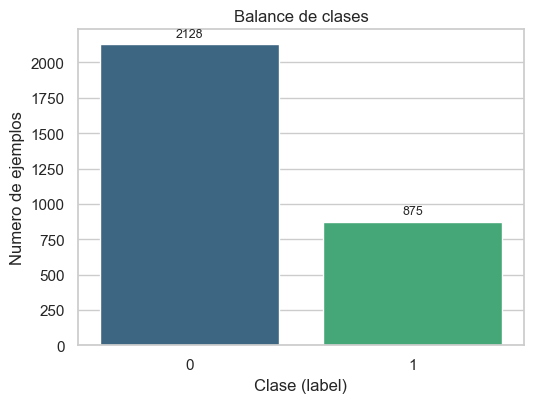

,count,mean,std,min,median,max,skew,kurtosis
Right Tibialis anterior__zc,3003.0,144.628039,31.434256,54.00000,149.00000,210.00000,-0.708563,0.062314
Left Gastrocnemius medialis__zc,3003.0,145.829504,24.337790,44.00000,151.00000,201.00000,-1.282924,1.940590
Left Gastrocnemius lateralis__zc,3003.0,136.709291,21.521794,66.00000,134.00000,214.00000,0.265452,0.467165
Left Gastrocnemius medialis__median_freq,3003.0,68.754163,19.136914,15.62500,70.31250,121.09375,-0.874746,0.589153
Left Semitendinosus__zc,3003.0,111.058608,18.390734,64.00000,110.00000,192.00000,0.280989,0.097048
Left Gluteus maximus__zc,3003.0,120.336996,17.928098,45.00000,122.00000,174.00000,-0.653451,1.253078
Right Tibialis anterior__median_freq,3003.0,65.956179,17.569974,19.53125,66.40625,121.09375,0.049843,-0.207484
Left Gastrocnemius lateralis__median_freq,3003.0,65.935367,16.929707,11.71875,66.40625,125.00000,-1.034409,1.756732
Left Biceps femoris caput longus__zc,3003.0,115.648019,16.170693,49.00000,117.00000,165.00000,-0.935065,2.103858
Left Semitendinosus__median_freq,3003.0,44.611638,15.289226,15.62500,42.96875,105.46875,0.957063,0.691364


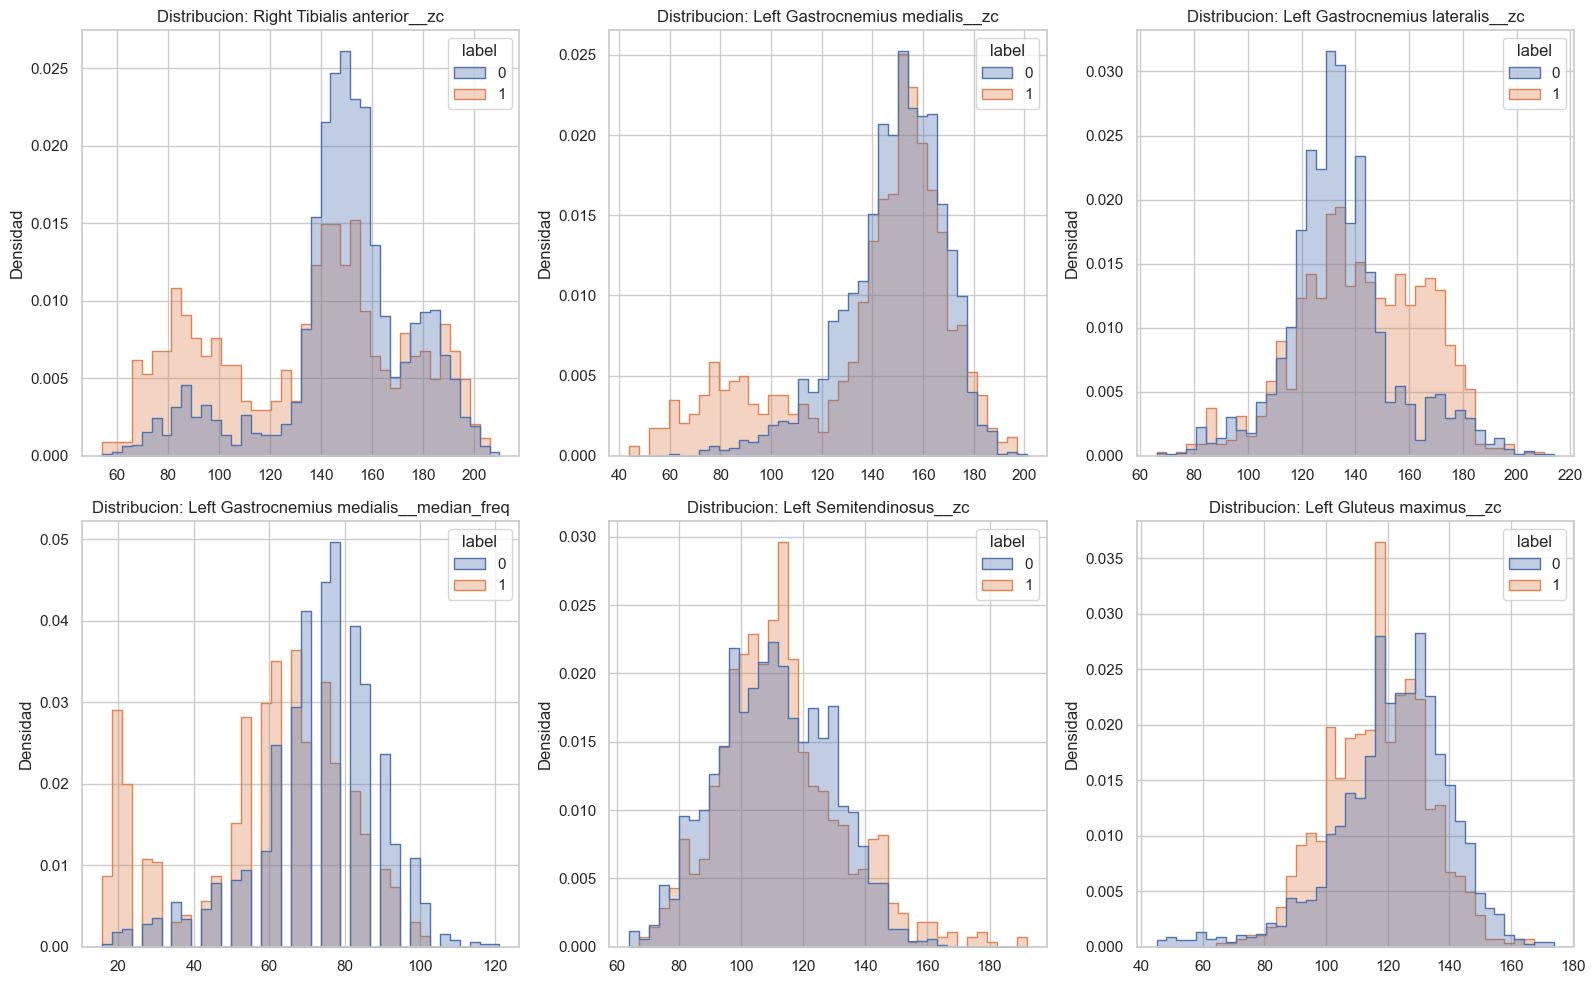

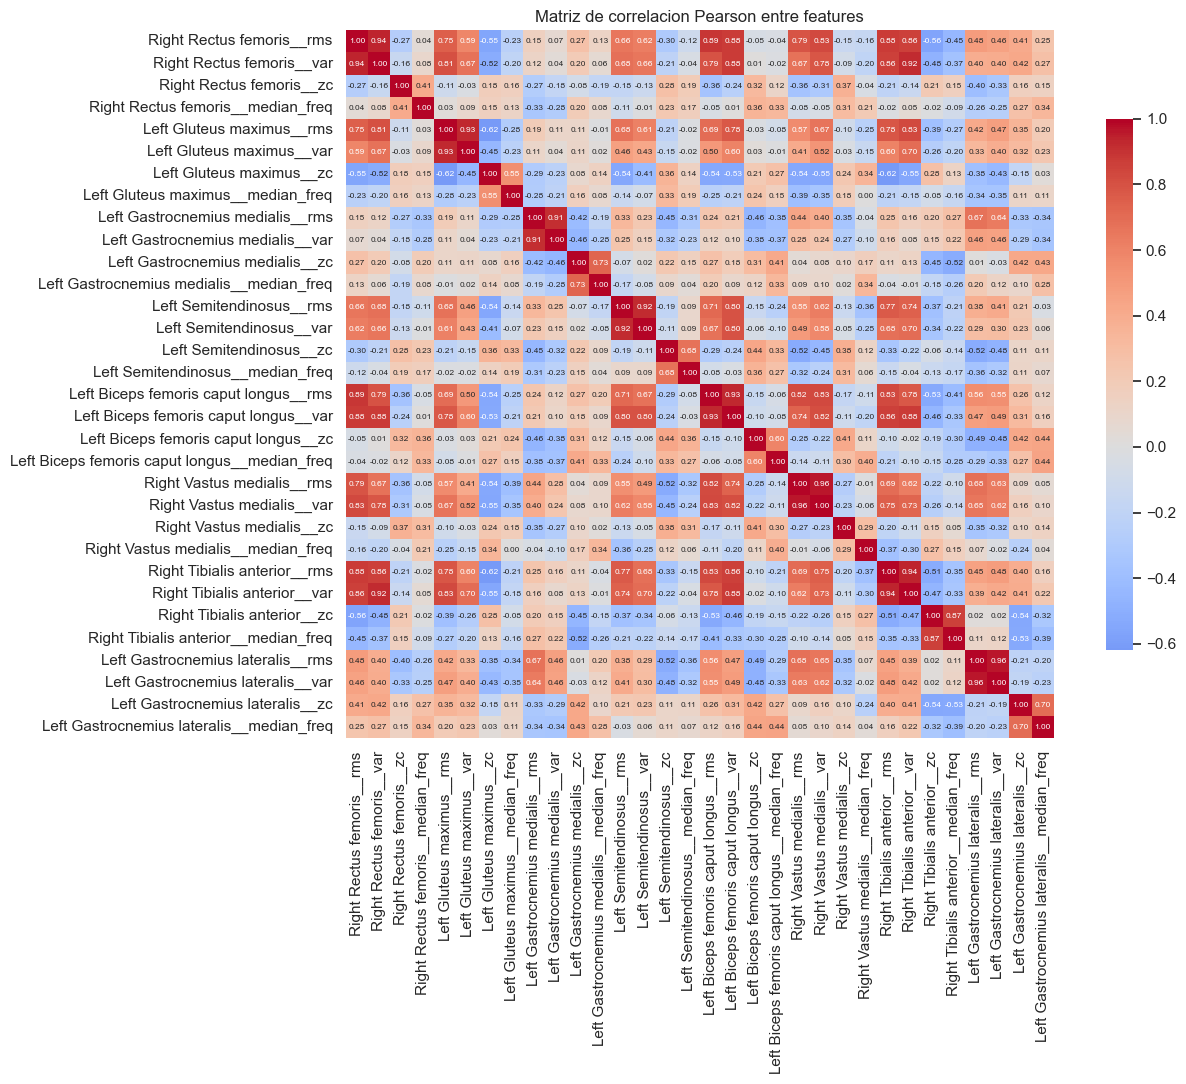

,mean_0,mean_1,diff_mean,abs_diff_mean,effect_score_abs
Left Gastrocnemius medialis__median_freq,73.121035,58.133929,-14.987106,14.987106,0.784651
Left Gastrocnemius lateralis__rms,0.055631,0.040131,-0.015500,0.015500,0.559288
Right Vastus medialis__median_freq,59.810782,52.964286,-6.846496,6.846496,0.551970
Left Gastrocnemius lateralis__var,0.004057,0.002184,-0.001872,0.001872,0.473452
Right Tibialis anterior__zc,149.116071,133.713143,-15.402929,15.402929,0.467338
Right Tibialis anterior__median_freq,68.383238,60.053571,-8.329667,8.329667,0.458878
Left Gastrocnemius lateralis__zc,134.330357,142.494857,8.164500,8.164500,0.372866
Left Gastrocnemius medialis__zc,148.571898,139.160000,-9.411898,9.411898,0.352003


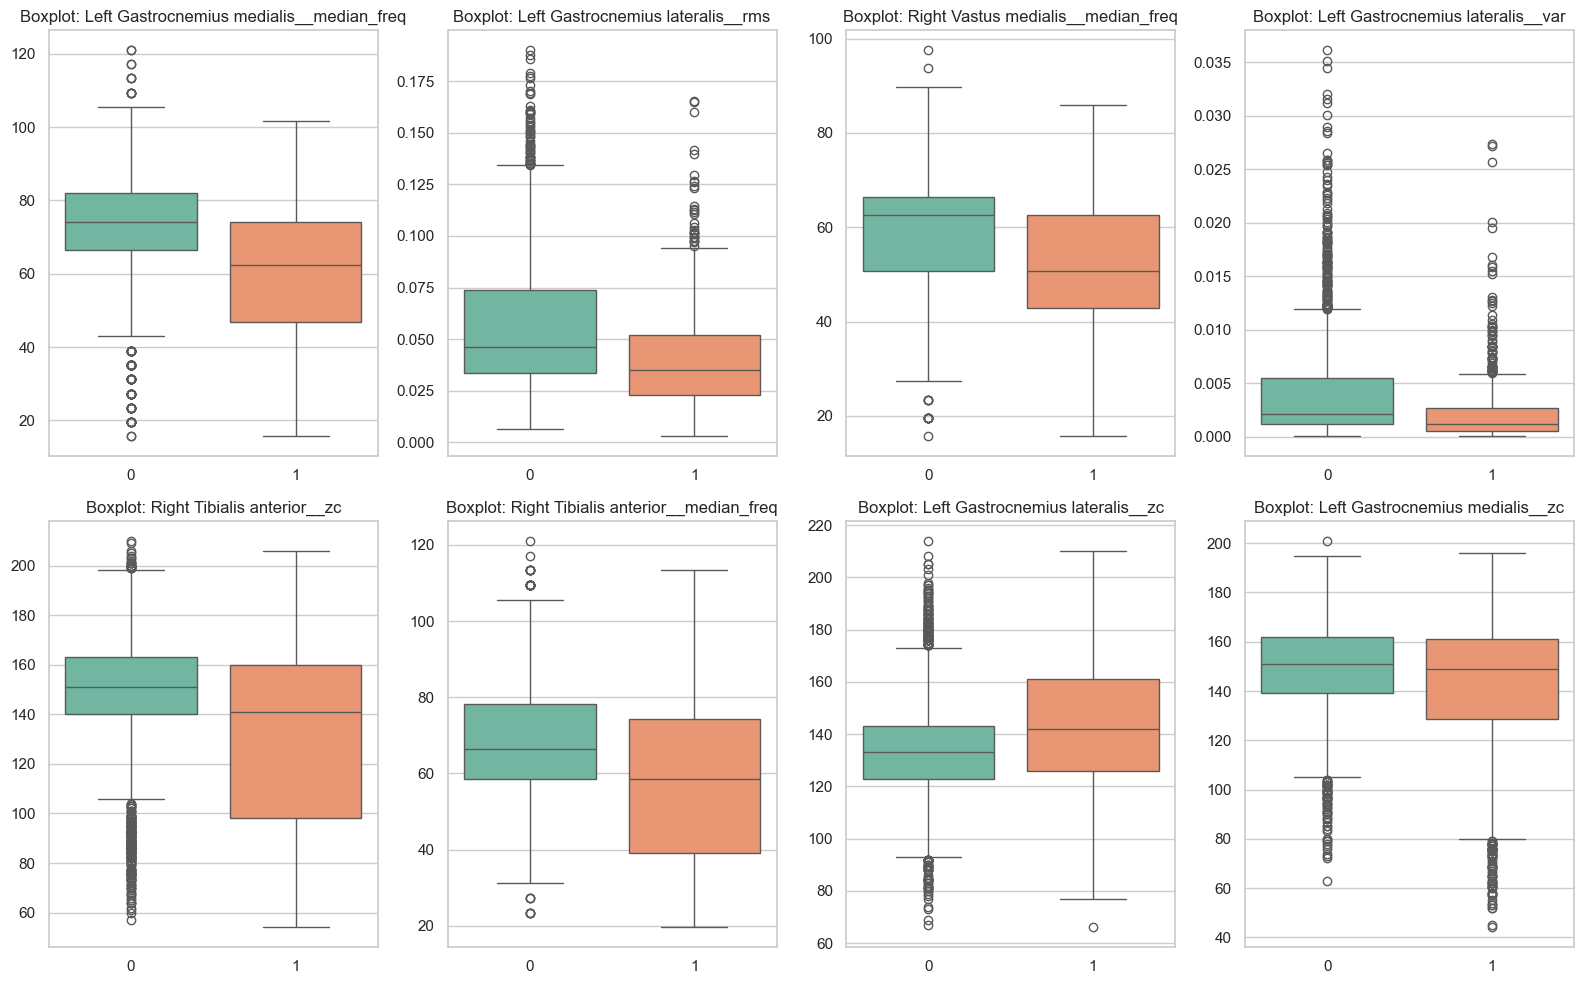

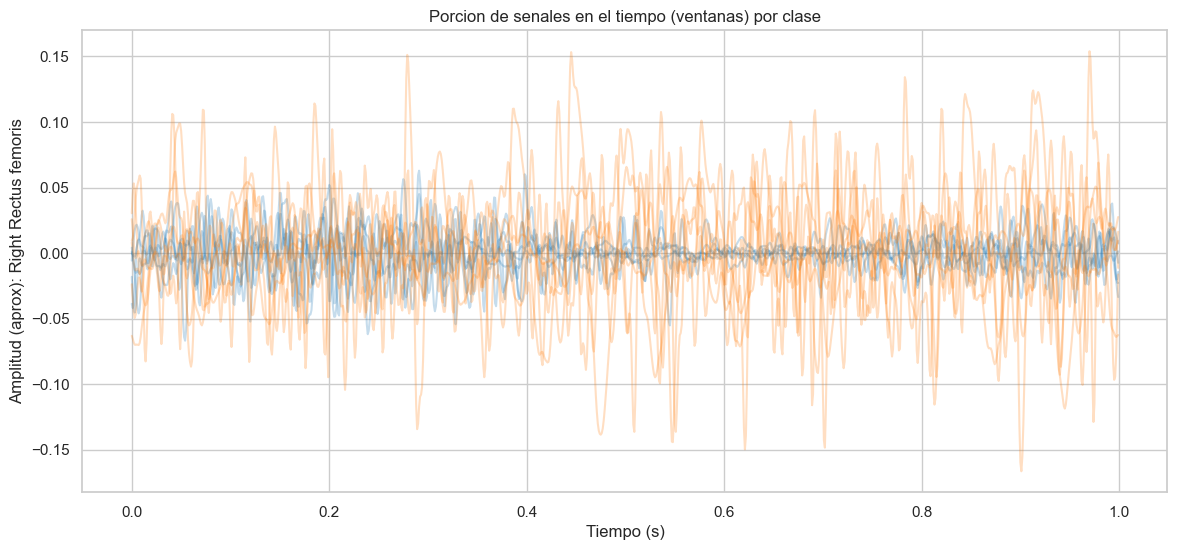

In [54]:




sns.set_theme(style="whitegrid")


assert "features_df" in globals(), "No existe features_df. Ejecuta antes la celda de creacion de features_df."

if "label" not in features_df.columns:
    raise ValueError("features_df no contiene la columna objetivo 'label'.")

target_col = "label"

feature_cols = [c for c in features_df.columns if c != target_col]


features_numeric = features_df[feature_cols].apply(pd.to_numeric, errors="coerce")

print("features_df shape:", features_df.shape)
print("#features:", len(feature_cols))
print("Total NaNs en features:", int(features_numeric.isna().sum().sum()))





class_counts = features_df[target_col].value_counts().sort_index()
class_props = (class_counts / len(features_df)).astype(float)



plt.figure(figsize=(5.5, 4.2))
ax = sns.barplot(x=class_counts.index.astype(str), y=class_counts.values, palette="viridis")
ax.set_xlabel("Clase (label)")
ax.set_ylabel("Numero de ejemplos")
ax.set_title("Balance de clases")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom", fontsize=9, xytext=(0, 3), textcoords="offset points")
plt.tight_layout()
plt.show()


summary_df = features_numeric.agg(["count", "mean", "std", "min", "median", "max"]).T
summary_df["skew"] = features_numeric.apply(skew)
summary_df["kurtosis"] = features_numeric.apply(kurtosis)



display(summary_df.sort_values("std", ascending=False).head(12))

# Distribuciones: elegir las mas variables para graficar
n_plot = 6
var_cols = features_numeric.var().sort_values(ascending=False).head(n_plot).index.tolist()

plt.figure(figsize=(16, 10))
for i, col in enumerate(var_cols, start=1):
    plt.subplot(2, 3, i)
    sns.histplot(
        data=features_df,
        x=col,
        hue=target_col,
        element="step",
        stat="density",
        common_norm=False,
        bins=40,
        alpha=0.35,
        kde=False,
    )
    plt.title(f"Distribucion: {col}")
    plt.xlabel("")
    plt.ylabel("Densidad")
plt.tight_layout()
plt.show()



corr = features_numeric.corr(method="pearson")


abs_corr = corr.abs().copy()
abs_corr_np = abs_corr.to_numpy().copy()
np.fill_diagonal(abs_corr_np, 0.0)
abs_corr = pd.DataFrame(abs_corr_np, index=abs_corr.index, columns=abs_corr.columns)
max_pair = abs_corr.stack().idxmax()  
max_corr = abs_corr.loc[max_pair[0], max_pair[1]]



plt.figure(figsize=(14, 11))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True,
    cbar_kws={"shrink": 0.75},
    annot=True,
    fmt=".2f",
    annot_kws={"size": 6},
)
plt.title("Matriz de correlacion Pearson entre features")
plt.tight_layout()
plt.show()


by_class = features_df.groupby(target_col)
means = by_class[feature_cols].mean()
stds = by_class[feature_cols].std(ddof=0)


if set(class_counts.index.tolist()) != {0, 1}:
    print("Se detectaron mas de dos clases o no estan exactamente 0 y 1. Ajusta el codigo para otras etiquetas.")
else:
    mean0 = means.loc[0]
    mean1 = means.loc[1]
    std0 = stds.loc[0].replace(0, np.nan)
    std1 = stds.loc[1].replace(0, np.nan)

    # Diferencia de medias
    mean_diff = (mean1 - mean0)
    abs_mean_diff = mean_diff.abs()

    pooled_std = np.sqrt((std0**2 + std1**2) / 2.0)
    effect_score = (mean_diff / pooled_std).replace([np.inf, -np.inf], np.nan).abs()

    sep_df = pd.DataFrame({
        "mean_0": mean0,
        "mean_1": mean1,
        "diff_mean": mean_diff,
        "abs_diff_mean": abs_mean_diff,
        "effect_score_abs": effect_score,
    }).sort_values("effect_score_abs", ascending=False)

    top_k = 8
    top_sep_cols = sep_df.head(top_k).index.tolist()

    display(sep_df.head(top_k))

    


    plt.figure(figsize=(16, 10))
    for i, col in enumerate(top_sep_cols, start=1):
        plt.subplot(2, 4, i)
        sns.boxplot(
            x=target_col,
            y=col,
            data=features_df,
            hue=target_col,
            palette="Set2",
            dodge=False,
            legend=False,
        )
        plt.title(f"Boxplot: {col}")
        plt.xlabel("")
        plt.ylabel("")
    plt.tight_layout()
    plt.show()

    


if "X" in globals() and "y" in globals():
    try:
    
        n_windows, window_size, n_channels = X.shape

        t = np.arange(window_size)
        if "fs" in globals():
            t = t / float(fs)

        
        ch_idx = 0
        if "channel_cols" in globals() and isinstance(channel_cols, (list, tuple)) and len(channel_cols) == n_channels:
            ch_name = channel_cols[ch_idx]
        else:
            ch_name = f"channel_{ch_idx}"

        
        idx0 = np.where(np.asarray(y) == 0)[0][:6]
        idx1 = np.where(np.asarray(y) == 1)[0][:6]

        plt.figure(figsize=(14, 6))
        for i, idx in enumerate(idx0):
            plt.plot(t, X[idx, :, ch_idx], color="#1f77b4", alpha=0.25)
        for i, idx in enumerate(idx1):
            plt.plot(t, X[idx, :, ch_idx], color="#ff7f0e", alpha=0.25)

        plt.xlabel("Tiempo (s)" if "fs" in globals() else "Muestra")
        plt.ylabel(f"Amplitud (aprox): {ch_name}")
        plt.title("Porcion de senales en el tiempo (ventanas) por clase")

       

        plt.show()
    

    except Exception as e:
        print("No se pudo generar el plot en el tiempo:", repr(e))
else:
    print("No existe X/y en el entorno; omito el plot de señales en el tiempo.")


In [55]:



assert "features_df" in globals(), "Ejecuta antes la celda que crea features_df."

if "label" not in features_df.columns:
    raise ValueError("features_df no tiene la columna 'label' como target.")

target_col = "label"
feature_cols = [c for c in features_df.columns if c != target_col]

X = features_df[feature_cols].copy()
X = X.apply(pd.to_numeric, errors="coerce")

y = features_df[target_col].astype(int).copy()



X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=0)

print("Tamaños:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)



preprocess_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# Fit SOLO en train para evitar leakage
X_train_processed = preprocess_pipeline.fit_transform(X_train)
X_val_processed = preprocess_pipeline.transform(X_val)
X_test_processed = preprocess_pipeline.transform(X_test)

print("\nValores nulos antes (total):")
print("train:", int(X_train.isna().sum().sum()), "val:", int(X_val.isna().sum().sum()), "test:", int(X_test.isna().sum().sum()))

print("\nProcesado listo.")
print("X_train_processed:", X_train_processed.shape)
print("X_val_processed:", X_val_processed.shape)
print("X_test_processed:", X_test_processed.shape)




Tamaños:
X_train: (1801, 32) y_train: (1801,)
X_val: (601, 32) y_val: (601,)
X_test: (601, 32) y_test: (601,)

Valores nulos antes (total):
train: 0 val: 0 test: 0

Procesado listo.
X_train_processed: (1801, 32)
X_val_processed: (601, 32)
X_test_processed: (601, 32)


---

# KNN

In [56]:



param_distribution = {
    "n_neighbors": randint(1, 71),
    "weights": ["uniform", "distance"],
    "p": [1, 2]
}
knn = KNeighborsClassifier()

random_search = RandomizedSearchCV(
    estimator=knn,
    param_distributions= param_distribution,
    n_iter=100,           
    scoring="accuracy",         
    cv=5,                 
    random_state=42,
    n_jobs=-1,            
    verbose=1,
)


random_search.fit(X_train_processed, y_train)


print(f"Mejor modelo: {random_search.best_estimator_}")
print(f"Mejor puntaje: {random_search.best_score_:.4f}")
print(f"Mejor parametros: {random_search.best_params_}")







Fitting 5 folds for each of 100 candidates, totalling 500 fits
Mejor modelo: KNeighborsClassifier(n_neighbors=7, p=1)
Mejor puntaje: 0.8484
Mejor parametros: {'n_neighbors': 7, 'p': 1, 'weights': 'uniform'}


Mejores datos implementado concatenación entre X_train y X_val

In [57]:

X_trainval_processed = np.concatenate([X_train_processed, X_val_processed], axis=0)
y_trainval = np.concatenate([y_train, y_val], axis=0)

knn_final = KNeighborsClassifier(
    n_neighbors=7,
    p=1,
    weights="uniform",
)

knn_final.fit(X_trainval_processed, y_trainval)

y_test_pred = knn_final.predict(X_test_processed)

print("=== Resultados en TRAIN ===\n")
y_train_pred = knn_final.predict(X_train_processed)
print(classification_report(y_train, y_train_pred, target_names=["No fatiga (0)", "Fatiga (1)"]))
print(f"Accuracy:       {accuracy_score(y_train, y_train_pred):.4f}")  
print(f"F1 (macro):     {f1_score(y_train, y_train_pred, average='macro'):.4f}")
print(f"F1 (clase 1):   {f1_score(y_train, y_train_pred, average='binary'):.4f}")


print("=== Resultados en TEST ===\n")
print(classification_report(y_test, y_test_pred, target_names=["No fatiga (0)", "Fatiga (1)"]))
print(f"Accuracy:       {accuracy_score(y_test, y_test_pred):.4f}")  
print(f"F1 (macro):     {f1_score(y_test, y_test_pred, average='macro'):.4f}")
print(f"F1 (clase 1):   {f1_score(y_test, y_test_pred, average='binary'):.4f}")





=== Resultados en TRAIN ===

               precision    recall  f1-score   support

No fatiga (0)       0.88      0.95      0.92      1271
   Fatiga (1)       0.86      0.70      0.77       530

     accuracy                           0.88      1801
    macro avg       0.87      0.82      0.84      1801
 weighted avg       0.88      0.88      0.87      1801

Accuracy:       0.8767
F1 (macro):     0.8426
F1 (clase 1):   0.7692
=== Resultados en TEST ===

               precision    recall  f1-score   support

No fatiga (0)       0.87      0.95      0.91       417
   Fatiga (1)       0.85      0.67      0.75       184

     accuracy                           0.86       601
    macro avg       0.86      0.81      0.83       601
 weighted avg       0.86      0.86      0.86       601

Accuracy:       0.8636
F1 (macro):     0.8281
F1 (clase 1):   0.7500


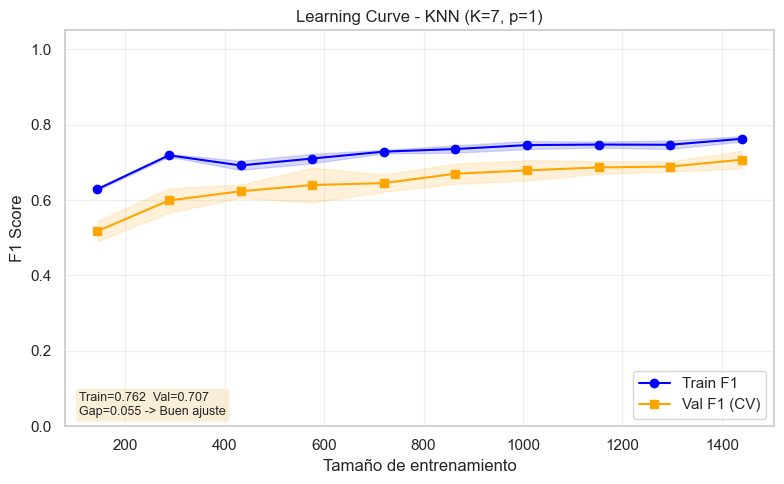

In [58]:
# Curva de aprendizaje - KNN
from sklearn.model_selection import learning_curve

knn_lc = KNeighborsClassifier(n_neighbors=7, p=1, weights="uniform")

train_sizes, train_scores, val_scores = learning_curve(
    knn_lc, X_train_processed, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10), cv=5, scoring="f1", n_jobs=-1, random_state=42
)

plt.figure(figsize=(8, 5))
plt.fill_between(train_sizes, train_scores.mean(1) - train_scores.std(1), train_scores.mean(1) + train_scores.std(1), alpha=0.15, color="blue")
plt.fill_between(train_sizes, val_scores.mean(1) - val_scores.std(1), val_scores.mean(1) + val_scores.std(1), alpha=0.15, color="orange")
plt.plot(train_sizes, train_scores.mean(1), "o-", color="blue", label="Train F1")
plt.plot(train_sizes, val_scores.mean(1), "s-", color="orange", label="Val F1 (CV)")
plt.xlabel("Tamaño de entrenamiento")
plt.ylabel("F1 Score")
plt.ylim(0, 1.05)
plt.title("Learning Curve - KNN (K=7, p=1)")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

gap = train_scores.mean(1)[-1] - val_scores.mean(1)[-1]
diag = "OVERFITTING" if gap > 0.10 else ("UNDERFITTING" if val_scores.mean(1)[-1] < 0.70 else "Buen ajuste")
plt.text(0.02, 0.02, f"Train={train_scores.mean(1)[-1]:.3f}  Val={val_scores.mean(1)[-1]:.3f}\nGap={gap:.3f} -> {diag}",
         transform=plt.gca().transAxes, fontsize=9, va="bottom", bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))
plt.tight_layout()
plt.show()


El entrenamiento de KNN mostró un comportamiento bueno, llegando casi hasta el 80% de efectividad en su predicción. y así mismo, su predicción de valoración también tuvo casi el 80% de predicción. Adicionalmente sus curvas están ligeramente cerca y suben con más datos.

Esto nos da a entender que son los datos con menor cantidad de overfitting demostrando que tiene un buen ajuste de aprendizaje

Mejores datos implementado concatenación entre X_train y X_val

---
# Decision Tree

In [59]:
param_distribution = {
    "max_depth": randint(1, 31),
    "min_samples_split": randint(2, 10),
    "min_samples_leaf": randint(1, 10),
    "max_features": ["sqrt", "log2"]
}

tree = DecisionTreeClassifier(random_state=42)

random_search = RandomizedSearchCV(
    estimator=tree,
    param_distributions=param_distribution,
    n_iter=100,
    scoring="accuracy",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train_processed, y_train)

print(f"Mejor modelo: {random_search.best_estimator_}")
print(f"Mejor puntaje: {random_search.best_score_:.4f}")
print(f"Mejor parametros: {random_search.best_params_}")



Fitting 5 folds for each of 100 candidates, totalling 500 fits
Mejor modelo: DecisionTreeClassifier(max_depth=7, max_features='log2', min_samples_leaf=8,
                       min_samples_split=6, random_state=42)
Mejor puntaje: 0.8068
Mejor parametros: {'max_depth': 7, 'max_features': 'log2', 'min_samples_leaf': 8, 'min_samples_split': 6}


In [60]:
X_trainval_processed_tree = np.concatenate([X_train_processed, X_val_processed], axis=0)
y_trainval_tree = np.concatenate([y_train, y_val], axis=0)

tree_final = DecisionTreeClassifier(
    max_depth=9,
    min_samples_split=3,
    min_samples_leaf=5,
    max_features="log2"
)

tree_final.fit(X_trainval_processed_tree, y_trainval_tree)

y_test_pred_tree = tree_final.predict(X_test_processed)

print("=== Resultados en TRAIN ===\n")
y_train_pred_tree = tree_final.predict(X_train_processed)
print(classification_report(y_train, y_train_pred_tree, target_names=["No fatiga (0)", "Fatiga (1)"]))
print(f"Accuracy:       {accuracy_score(y_train, y_train_pred_tree):.4f}")  
print(f"F1 (macro):     {f1_score(y_train, y_train_pred_tree, average='macro'):.4f}")
print(f"F1 (clase 1):   {f1_score(y_train, y_train_pred_tree, average='binary'):.4f}")



print("=== Resultados en TEST ===\n")
print(classification_report(y_test, y_test_pred_tree, target_names=["No fatiga (0)", "Fatiga (1)"]))
print(f"Accuracy:       {accuracy_score(y_test, y_test_pred_tree):.4f}")
print(f"F1 (macro):     {f1_score(y_test, y_test_pred_tree, average='macro'):.4f}")
print(f"F1 (clase 1):   {f1_score(y_test, y_test_pred_tree, average='binary'):.4f}")




=== Resultados en TRAIN ===

               precision    recall  f1-score   support

No fatiga (0)       0.89      0.94      0.92      1271
   Fatiga (1)       0.84      0.72      0.78       530

     accuracy                           0.88      1801
    macro avg       0.87      0.83      0.85      1801
 weighted avg       0.88      0.88      0.87      1801

Accuracy:       0.8778
F1 (macro):     0.8462
F1 (clase 1):   0.7764
=== Resultados en TEST ===

               precision    recall  f1-score   support

No fatiga (0)       0.83      0.89      0.86       417
   Fatiga (1)       0.70      0.58      0.63       184

     accuracy                           0.80       601
    macro avg       0.76      0.73      0.75       601
 weighted avg       0.79      0.80      0.79       601

Accuracy:       0.7953
F1 (macro):     0.7455
F1 (clase 1):   0.6328


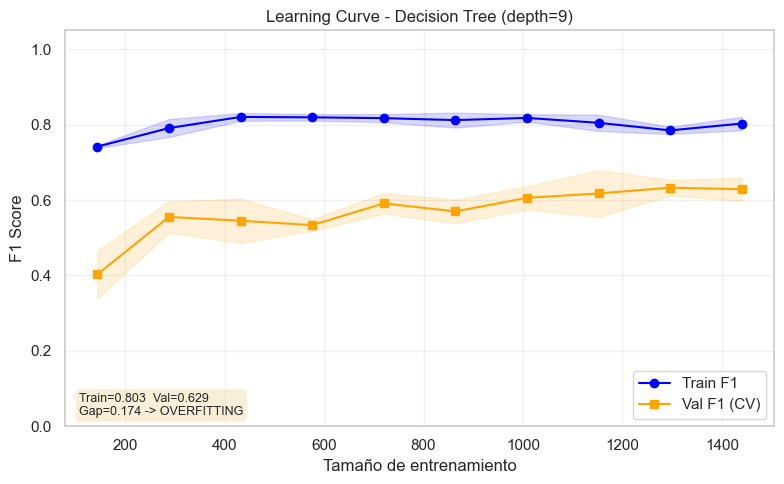

In [61]:
# Curva de aprendizaje - Decision Tree
from sklearn.tree import DecisionTreeClassifier

tree_lc = DecisionTreeClassifier(max_depth=9, min_samples_split=3, min_samples_leaf=5, max_features="log2", random_state=42)

train_sizes, train_scores, val_scores = learning_curve(
    tree_lc, X_train_processed, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10), cv=5, scoring="f1", n_jobs=-1, random_state=42
)

plt.figure(figsize=(8, 5))
plt.fill_between(train_sizes, train_scores.mean(1) - train_scores.std(1), train_scores.mean(1) + train_scores.std(1), alpha=0.15, color="blue")
plt.fill_between(train_sizes, val_scores.mean(1) - val_scores.std(1), val_scores.mean(1) + val_scores.std(1), alpha=0.15, color="orange")
plt.plot(train_sizes, train_scores.mean(1), "o-", color="blue", label="Train F1")
plt.plot(train_sizes, val_scores.mean(1), "s-", color="orange", label="Val F1 (CV)")
plt.xlabel("Tamaño de entrenamiento")
plt.ylabel("F1 Score")
plt.ylim(0, 1.05)
plt.title("Learning Curve - Decision Tree (depth=9)")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

gap = train_scores.mean(1)[-1] - val_scores.mean(1)[-1]
diag = "OVERFITTING" if gap > 0.10 else ("UNDERFITTING" if val_scores.mean(1)[-1] < 0.70 else "Buen ajuste")
plt.text(0.02, 0.02, f"Train={train_scores.mean(1)[-1]:.3f}  Val={val_scores.mean(1)[-1]:.3f}\nGap={gap:.3f} -> {diag}",
         transform=plt.gca().transAxes, fontsize=9, va="bottom", bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))
plt.tight_layout()
plt.show()


Como se puede ver en la gráfica, los datos de train siempre estuvieron por encima del 80% mientras que la valoración quedó siempre bajo el 60%. Adicionalmente, las gráficas fueron diferentes y train fue constante dando a entender de que tuvo un Overfitting. No fue muy favorable.

---
# Random Forest

In [62]:
param_distribution = {
    "n_estimators": randint(10, 1001),
    "max_depth": randint(1, 31),
    "min_samples_split": randint(2, 10),
    "min_samples_leaf": randint(1, 10),
    "max_features": ["sqrt", "log2"],
    "class_weight": ["balanced", "balanced_subsample"]
}

rf = RandomForestClassifier(random_state=42)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_distribution,
    n_iter=100,
    scoring="accuracy",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train_processed, y_train)

print(f"Mejor modelo: {random_search.best_estimator_}")
print(f"Mejor puntaje: {random_search.best_score_:.4f}")
print(f"Mejor parametros: {random_search.best_params_}")



Fitting 5 folds for each of 100 candidates, totalling 500 fits
Mejor modelo: RandomForestClassifier(class_weight='balanced_subsample', max_depth=21,
                       min_samples_split=8, n_estimators=811, random_state=42)
Mejor puntaje: 0.8695
Mejor parametros: {'class_weight': 'balanced_subsample', 'max_depth': 21, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 8, 'n_estimators': 811}


Mejores datos implementado concatenación entre X_train y X_val

In [63]:
X_trainval_processed_rf = np.concatenate([X_train_processed, X_val_processed], axis=0)
y_trainval_rf = np.concatenate([y_train, y_val], axis=0)

rf_final = RandomForestClassifier(
    n_estimators=811,
    max_depth=21,
    min_samples_split=8,
    min_samples_leaf=1,
    max_features="sqrt",
    class_weight="balanced_subsample"
)

rf_final.fit(X_trainval_processed_rf, y_trainval_rf)

y_test_pred_rf = rf_final.predict(X_test_processed)

print("=== Resultados en TRAIN ===\n")
y_train_pred_rf = rf_final.predict(X_train_processed)
print(classification_report(y_train, y_train_pred_rf, target_names=["No fatiga (0)", "Fatiga (1)"]))
print(f"Accuracy:       {accuracy_score(y_train, y_train_pred_rf):.4f}")  
print(f"F1 (macro):     {f1_score(y_train, y_train_pred_rf, average='macro'):.4f}")
print(f"F1 (clase 1):   {f1_score(y_train, y_train_pred_rf, average='binary'):.4f}")



print("=== Resultados en TEST ===\n")
print(classification_report(y_test, y_test_pred_rf, target_names=["No fatiga (0)", "Fatiga (1)"]))
print(f"Accuracy:       {accuracy_score(y_test, y_test_pred_rf):.4f}")
print(f"F1 (macro):     {f1_score(y_test, y_test_pred_rf, average='macro'):.4f}")
print(f"F1 (clase 1):   {f1_score(y_test, y_test_pred_rf, average='binary'):.4f}")


=== Resultados en TRAIN ===

               precision    recall  f1-score   support

No fatiga (0)       1.00      0.99      1.00      1271
   Fatiga (1)       0.98      1.00      0.99       530

     accuracy                           0.99      1801
    macro avg       0.99      0.99      0.99      1801
 weighted avg       0.99      0.99      0.99      1801

Accuracy:       0.9933
F1 (macro):     0.9920
F1 (clase 1):   0.9888
=== Resultados en TEST ===

               precision    recall  f1-score   support

No fatiga (0)       0.89      0.95      0.92       417
   Fatiga (1)       0.87      0.74      0.80       184

     accuracy                           0.89       601
    macro avg       0.88      0.84      0.86       601
 weighted avg       0.88      0.89      0.88       601

Accuracy:       0.8852
F1 (macro):     0.8588
F1 (clase 1):   0.7977


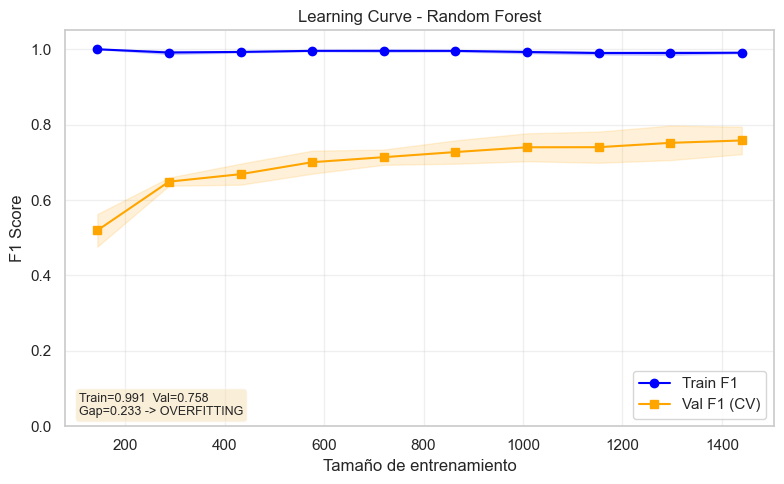

In [64]:
# Curva de aprendizaje - Random Forest
rf_lc = RandomForestClassifier(
    n_estimators=811, max_depth=21, min_samples_split=8,
    min_samples_leaf=1, max_features="sqrt",
    class_weight="balanced_subsample", random_state=42
)

train_sizes, train_scores, val_scores = learning_curve(
    rf_lc, X_train_processed, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10), cv=5, scoring="f1", n_jobs=-1, random_state=42
)

plt.figure(figsize=(8, 5))
plt.fill_between(train_sizes, train_scores.mean(1) - train_scores.std(1), train_scores.mean(1) + train_scores.std(1), alpha=0.15, color="blue")
plt.fill_between(train_sizes, val_scores.mean(1) - val_scores.std(1), val_scores.mean(1) + val_scores.std(1), alpha=0.15, color="orange")
plt.plot(train_sizes, train_scores.mean(1), "o-", color="blue", label="Train F1")
plt.plot(train_sizes, val_scores.mean(1), "s-", color="orange", label="Val F1 (CV)")
plt.xlabel("Tamaño de entrenamiento")
plt.ylabel("F1 Score")
plt.ylim(0, 1.05)
plt.title("Learning Curve - Random Forest")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

gap = train_scores.mean(1)[-1] - val_scores.mean(1)[-1]
diag = "OVERFITTING" if gap > 0.10 else ("UNDERFITTING" if val_scores.mean(1)[-1] < 0.70 else "Buen ajuste")
plt.text(0.02, 0.02, f"Train={train_scores.mean(1)[-1]:.3f}  Val={val_scores.mean(1)[-1]:.3f}\nGap={gap:.3f} -> {diag}",
         transform=plt.gca().transAxes, fontsize=9, va="bottom", bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))
plt.tight_layout()
plt.show()


En random forest tuvo un Train de casí 100% mientras que la valoración estuvo entre 58% y casi el 80% Eso significa de que hay un overfitting severo por lo que también las dos gráficas son completamente diferentes. No es muy rentable.

---
# Gradient Boosting

In [65]:
param_distribution = {
    "n_estimators": randint(10, 1001),
    "max_depth": randint(1, 31),
    "learning_rate": [0.01, 0.1, 1],
    "subsample": [0.5, 0.75, 1],
    "min_samples_split": randint(2, 10),
    "min_samples_leaf": randint(1, 10)
}

gb = GradientBoostingClassifier(random_state=42)

random_search = RandomizedSearchCV(
    estimator=gb,
    param_distributions=param_distribution,
    n_iter=100,
    scoring="accuracy",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train_processed, y_train)

print(f"Mejor modelo: {random_search.best_estimator_}")
print(f"Mejor puntaje: {random_search.best_score_:.4f}")
print(f"Mejor parametros: {random_search.best_params_}")


Fitting 5 folds for each of 100 candidates, totalling 500 fits
Mejor modelo: GradientBoostingClassifier(max_depth=21, min_samples_leaf=4,
                           min_samples_split=9, n_estimators=905,
                           random_state=42, subsample=1)
Mejor puntaje: 0.8801
Mejor parametros: {'learning_rate': 0.1, 'max_depth': 21, 'min_samples_leaf': 4, 'min_samples_split': 9, 'n_estimators': 905, 'subsample': 1}


Mejores datos implementado concatenación entre X_train y X_val

In [66]:
X_trainval_processed_gb = np.concatenate([X_train_processed, X_val_processed], axis=0)
y_trainval_gb = np.concatenate([y_train, y_val], axis=0)

gb_final = GradientBoostingClassifier(
    n_estimators=905,
    max_depth=21,
    learning_rate=0.1,
    subsample=1,
    min_samples_split=9,
    min_samples_leaf=4
)

gb_final.fit(X_trainval_processed_gb, y_trainval_gb)

y_test_pred_gb = gb_final.predict(X_test_processed)



print("=== Resultados en TRAIN ===\n")
y_train_pred_gb = gb_final.predict(X_train_processed)
print(classification_report(y_train, y_train_pred_gb, target_names=["No fatiga (0)", "Fatiga (1)"]))
print(f"Accuracy:       {accuracy_score(y_train, y_train_pred_gb):.4f}")  
print(f"F1 (macro):     {f1_score(y_train, y_train_pred_gb, average='macro'):.4f}")
print(f"F1 (clase 1):   {f1_score(y_train, y_train_pred_gb, average='binary'):.4f}")



print("=== Resultados en TEST ===\n")
print(classification_report(y_test, y_test_pred_gb, target_names=["No fatiga (0)", "Fatiga (1)"]))
print(f"Accuracy:       {accuracy_score(y_test, y_test_pred_gb):.4f}")  
print(f"F1 (macro):     {f1_score(y_test, y_test_pred_gb, average='macro'):.4f}")
print(f"F1 (clase 1):   {f1_score(y_test, y_test_pred_gb, average='binary'):.4f}")



=== Resultados en TRAIN ===

               precision    recall  f1-score   support

No fatiga (0)       1.00      1.00      1.00      1271
   Fatiga (1)       1.00      1.00      1.00       530

     accuracy                           1.00      1801
    macro avg       1.00      1.00      1.00      1801
 weighted avg       1.00      1.00      1.00      1801

Accuracy:       1.0000
F1 (macro):     1.0000
F1 (clase 1):   1.0000
=== Resultados en TEST ===

               precision    recall  f1-score   support

No fatiga (0)       0.88      0.95      0.91       417
   Fatiga (1)       0.87      0.70      0.77       184

     accuracy                           0.88       601
    macro avg       0.87      0.83      0.84       601
 weighted avg       0.87      0.88      0.87       601

Accuracy:       0.8752
F1 (macro):     0.8442
F1 (clase 1):   0.7748


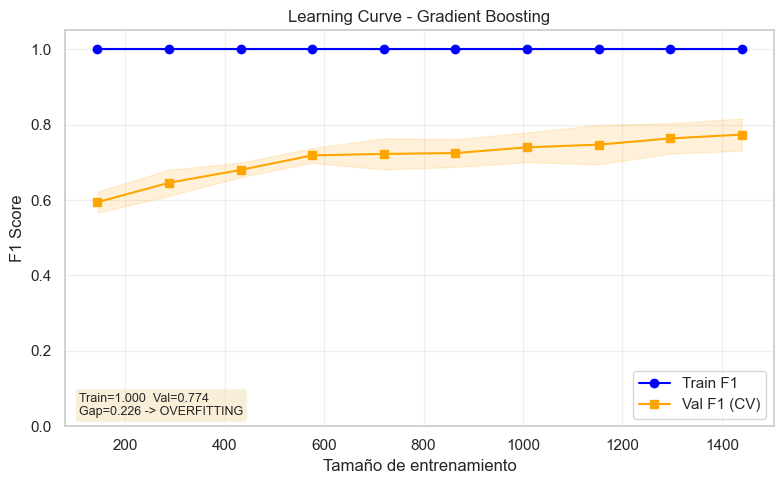

In [67]:
# Curva de aprendizaje - Gradient Boosting
gb_lc = GradientBoostingClassifier(
    n_estimators=905, max_depth=21, learning_rate=0.1,
    subsample=1, min_samples_split=9, min_samples_leaf=4, random_state=42
)

train_sizes, train_scores, val_scores = learning_curve(
    gb_lc, X_train_processed, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10), cv=5, scoring="f1", n_jobs=-1, random_state=42
)

plt.figure(figsize=(8, 5))
plt.fill_between(train_sizes, train_scores.mean(1) - train_scores.std(1), train_scores.mean(1) + train_scores.std(1), alpha=0.15, color="blue")
plt.fill_between(train_sizes, val_scores.mean(1) - val_scores.std(1), val_scores.mean(1) + val_scores.std(1), alpha=0.15, color="orange")
plt.plot(train_sizes, train_scores.mean(1), "o-", color="blue", label="Train F1")
plt.plot(train_sizes, val_scores.mean(1), "s-", color="orange", label="Val F1 (CV)")
plt.xlabel("Tamaño de entrenamiento")
plt.ylabel("F1 Score")
plt.ylim(0, 1.05)
plt.title("Learning Curve - Gradient Boosting")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

gap = train_scores.mean(1)[-1] - val_scores.mean(1)[-1]
diag = "OVERFITTING" if gap > 0.10 else ("UNDERFITTING" if val_scores.mean(1)[-1] < 0.70 else "Buen ajuste")
plt.text(0.02, 0.02, f"Train={train_scores.mean(1)[-1]:.3f}  Val={val_scores.mean(1)[-1]:.3f}\nGap={gap:.3f} -> {diag}",
         transform=plt.gca().transAxes, fontsize=9, va="bottom", bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))
plt.tight_layout()
plt.show()


En gradient boosting tuvo un Train del 100% mientras que la valoración estuvo entre 60% y casi el 80% Eso significa de que hay un overfitting severo por lo que también las dos gráficas son completamente diferentes. No es rentable.

---
# Deep Neural Network

In [68]:
mlp = MLPClassifier(random_state=42)

param_distribution_mlp = {
    "hidden_layer_sizes": [
        (256, 128), (256, 128, 64), (512, 256),
        (512, 256, 128), (256, 256), (512, 256, 128, 64),
        (256, 128, 64, 32), (512, 512),
    ],
    "activation": ["relu", "tanh"],
    "solver": ["adam"],
    "alpha": [1e-5, 5e-5, 1e-4, 5e-4, 1e-3],
    "learning_rate": ["constant", "adaptive"],
    "learning_rate_init": [0.0001, 0.0005, 0.001, 0.005],
    "batch_size": [16, 32, 64, 128],
    "max_iter": [1000],
    "early_stopping": [True],
    "n_iter_no_change": [15],
    "validation_fraction": [0.15],
}

random_search_mlp = RandomizedSearchCV(
    estimator=mlp,
    param_distributions=param_distribution_mlp,
    n_iter=60,
    scoring="accuracy",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)
random_search_mlp.fit(X_trainval_processed, y_trainval)

print(f"Mejor modelo: {random_search_mlp.best_estimator_}")
print(f"Mejor puntaje en accuracy: {random_search_mlp.best_score_:.4f}")
print(f"Mejor parametros: {random_search_mlp.best_params_}")





Fitting 5 folds for each of 60 candidates, totalling 300 fits
Mejor modelo: MLPClassifier(activation='tanh', alpha=1e-05, batch_size=64,
              early_stopping=True, hidden_layer_sizes=(256, 128), max_iter=1000,
              n_iter_no_change=15, random_state=42, validation_fraction=0.15)
Mejor puntaje en accuracy: 0.8639
Mejor parametros: {'validation_fraction': 0.15, 'solver': 'adam', 'n_iter_no_change': 15, 'max_iter': 1000, 'learning_rate_init': 0.001, 'learning_rate': 'constant', 'hidden_layer_sizes': (256, 128), 'early_stopping': True, 'batch_size': 64, 'alpha': 1e-05, 'activation': 'tanh'}


In [69]:
X_trainval_processed_mlp = np.concatenate([X_train_processed, X_val_processed], axis=0)
y_trainval_mlp = np.concatenate([y_train, y_val], axis=0)

mlp_final = MLPClassifier(
    hidden_layer_sizes=(256, 128),
    activation="tanh",
    solver="adam",
    alpha=1e-05,
    learning_rate="constant",
    learning_rate_init=0.001,
    batch_size=64,
    early_stopping=True,
    max_iter=1000,
    n_iter_no_change=15,
    validation_fraction=0.15,
)

mlp_final.fit(X_trainval_processed_mlp, y_trainval_mlp) 

y_test_pred_mlp = mlp_final.predict(X_test_processed)

print("=== Resultados en TRAIN ===\n")
y_train_pred_mlp = mlp_final.predict(X_train_processed)
print(classification_report(y_train, y_train_pred_mlp, target_names=["No fatiga (0)", "Fatiga (1)"]))
print(f"Accuracy:       {accuracy_score(y_train, y_train_pred_mlp):.4f}")  
print(f"F1 (macro):     {f1_score(y_train, y_train_pred_mlp, average='macro'):.4f}")
print(f"F1 (clase 1):   {f1_score(y_train, y_train_pred_mlp, average='binary'):.4f}")



print("=== Resultados en TEST ===\n")
print(classification_report(y_test, y_test_pred_mlp, target_names=["No fatiga (0)", "Fatiga (1)"]))
print(f"Accuracy:       {accuracy_score(y_test, y_test_pred_mlp):.4f}")  
print(f"F1 (macro):     {f1_score(y_test, y_test_pred_mlp, average='macro'):.4f}")
print(f"F1 (clase 1):   {f1_score(y_test, y_test_pred_mlp, average='binary'):.4f}")





=== Resultados en TRAIN ===

               precision    recall  f1-score   support

No fatiga (0)       0.90      0.96      0.93      1271
   Fatiga (1)       0.89      0.74      0.81       530

     accuracy                           0.90      1801
    macro avg       0.90      0.85      0.87      1801
 weighted avg       0.90      0.90      0.89      1801

Accuracy:       0.8973
F1 (macro):     0.8694
F1 (clase 1):   0.8091
=== Resultados en TEST ===

               precision    recall  f1-score   support

No fatiga (0)       0.89      0.96      0.92       417
   Fatiga (1)       0.89      0.72      0.80       184

     accuracy                           0.89       601
    macro avg       0.89      0.84      0.86       601
 weighted avg       0.89      0.89      0.88       601

Accuracy:       0.8869
F1 (macro):     0.8590
F1 (clase 1):   0.7964


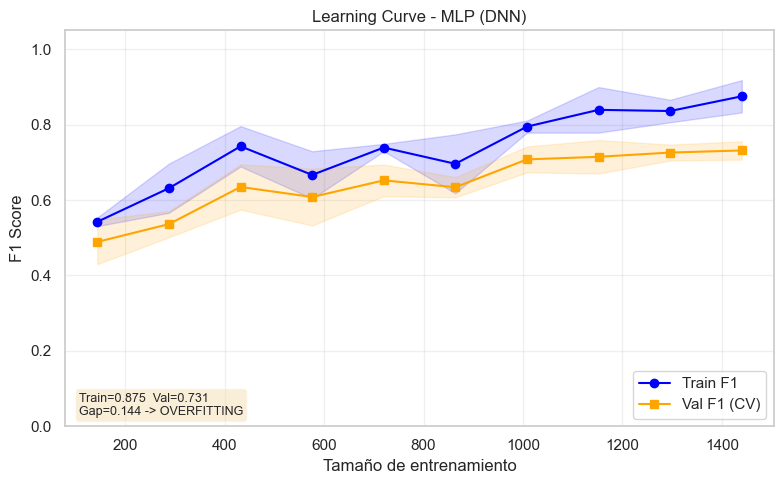

In [70]:
# Curva de aprendizaje - MLP (Deep Neural Network)
mlp_lc = MLPClassifier(
    hidden_layer_sizes=(256, 128), activation="tanh", solver="adam",
    alpha=1e-05, learning_rate="constant", learning_rate_init=0.001,
    batch_size=64, early_stopping=True, max_iter=1000,
    n_iter_no_change=15, validation_fraction=0.15, random_state=42
)

train_sizes, train_scores, val_scores = learning_curve(
    mlp_lc, X_train_processed, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10), cv=5, scoring="f1", n_jobs=-1, random_state=42
)

plt.figure(figsize=(8, 5))
plt.fill_between(train_sizes, train_scores.mean(1) - train_scores.std(1), train_scores.mean(1) + train_scores.std(1), alpha=0.15, color="blue")
plt.fill_between(train_sizes, val_scores.mean(1) - val_scores.std(1), val_scores.mean(1) + val_scores.std(1), alpha=0.15, color="orange")
plt.plot(train_sizes, train_scores.mean(1), "o-", color="blue", label="Train F1")
plt.plot(train_sizes, val_scores.mean(1), "s-", color="orange", label="Val F1 (CV)")
plt.xlabel("Tamaño de entrenamiento")
plt.ylabel("F1 Score")
plt.ylim(0, 1.05)
plt.title("Learning Curve - MLP (DNN)")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

gap = train_scores.mean(1)[-1] - val_scores.mean(1)[-1]
diag = "OVERFITTING" if gap > 0.10 else ("UNDERFITTING" if val_scores.mean(1)[-1] < 0.70 else "Buen ajuste")
plt.text(0.02, 0.02, f"Train={train_scores.mean(1)[-1]:.3f}  Val={val_scores.mean(1)[-1]:.3f}\nGap={gap:.3f} -> {diag}",
         transform=plt.gca().transAxes, fontsize=9, va="bottom", bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))
plt.tight_layout()
plt.show()


En el deep neural network tiene muestra un buen comportamiento de entrenamiento sin embargo, como la gráfica nunca se estabiliza muestra un overfitting moderado.

TABLA COMPARATIVA DE METRICAS EN TEST


,Modelo,Accuracy (test),F1 macro (test),F1 clase 1 (test),Precision clase 1 (test),Recall clase 1 (test)
0,KNN (K=7),0.863600,0.828100,0.750000,0.854200,0.668500
1,Decision Tree,0.795300,0.745500,0.632800,0.702000,0.576100
2,Random Forest,0.885200,0.858800,0.797700,0.866200,0.739100
3,Gradient Boosting,0.875200,0.844200,0.774800,0.865800,0.701100
4,MLP (DNN),0.886900,0.859000,0.796400,0.886700,0.722800



CLASSIFICATION REPORT - MEJOR MODELO: MLP (DNN)
               precision    recall  f1-score   support

No fatiga (0)       0.89      0.96      0.92       417
   Fatiga (1)       0.89      0.72      0.80       184

     accuracy                           0.89       601
    macro avg       0.89      0.84      0.86       601
 weighted avg       0.89      0.89      0.88       601



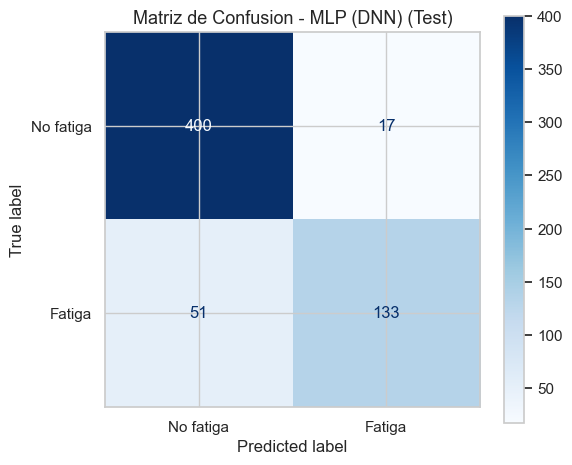

Verdaderos Negativos (TN): 400 | Falsos Positivos (FP): 17
Falsos Negativos (FN): 51 | Verdaderos Positivos (TP): 133

El modelo clasifica correctamente 133/184 (72.3%) de las muestras con fatiga
y correctamente 400/417 (95.9%) de las muestras sin fatiga.


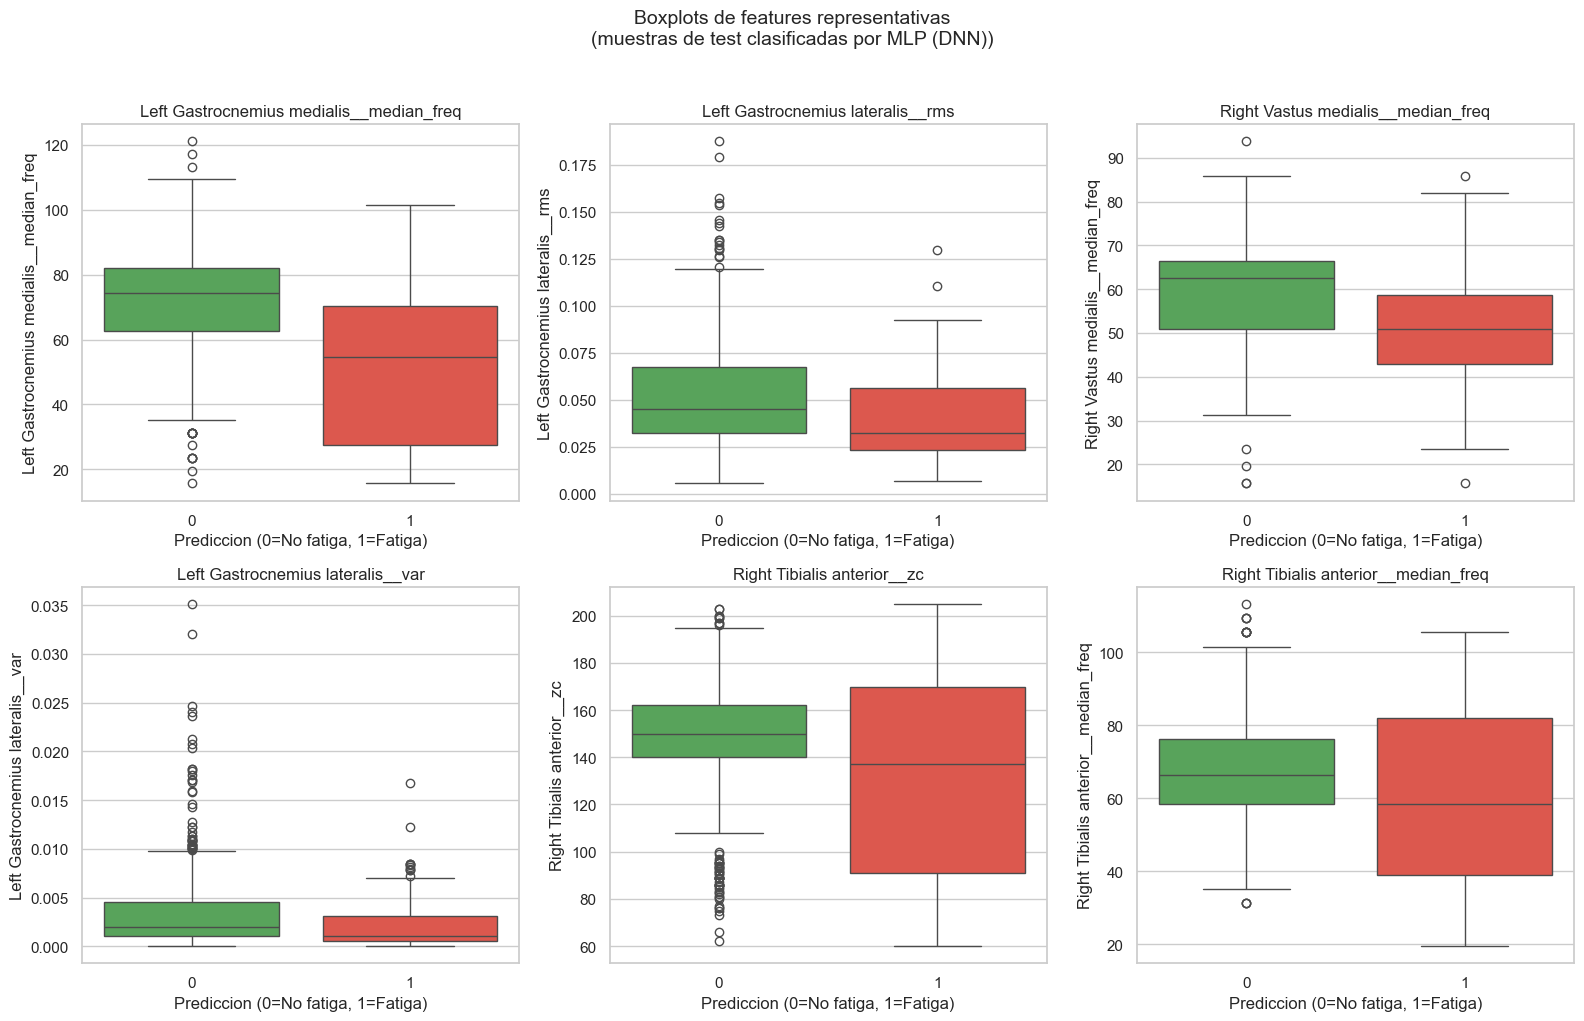

In [74]:





best_model_name = "MLP (DNN)"
y_pred_final = y_test_pred_mlp


metrics_table = pd.DataFrame({
    "Modelo": ["KNN (K=7)", "Decision Tree", "Random Forest", "Gradient Boosting", "MLP (DNN)"],
    "Accuracy (test)": [
        accuracy_score(y_test, y_test_pred),
        accuracy_score(y_test, y_test_pred_tree),
        accuracy_score(y_test, y_test_pred_rf),
        accuracy_score(y_test, y_test_pred_gb),
        accuracy_score(y_test, y_test_pred_mlp),
    ],
    "F1 macro (test)": [
        f1_score(y_test, y_test_pred, average="macro"),
        f1_score(y_test, y_test_pred_tree, average="macro"),
        f1_score(y_test, y_test_pred_rf, average="macro"),
        f1_score(y_test, y_test_pred_gb, average="macro"),
        f1_score(y_test, y_test_pred_mlp, average="macro"),
    ],
    "F1 clase 1 (test)": [
        f1_score(y_test, y_test_pred, average="binary"),
        f1_score(y_test, y_test_pred_tree, average="binary"),
        f1_score(y_test, y_test_pred_rf, average="binary"),
        f1_score(y_test, y_test_pred_gb, average="binary"),
        f1_score(y_test, y_test_pred_mlp, average="binary"),
    ],
    "Precision clase 1 (test)": [
        precision_score(y_test, y_test_pred, zero_division=0),
        precision_score(y_test, y_test_pred_tree, zero_division=0),
        precision_score(y_test, y_test_pred_rf, zero_division=0),
        precision_score(y_test, y_test_pred_gb, zero_division=0),
        precision_score(y_test, y_test_pred_mlp, zero_division=0),
    ],
    "Recall clase 1 (test)": [
        recall_score(y_test, y_test_pred, zero_division=0),
        recall_score(y_test, y_test_pred_tree, zero_division=0),
        recall_score(y_test, y_test_pred_rf, zero_division=0),
        recall_score(y_test, y_test_pred_gb, zero_division=0),
        recall_score(y_test, y_test_pred_mlp, zero_division=0),
    ],
})

metrics_table = metrics_table.round(4)
print("=" * 90)
print("TABLA COMPARATIVA DE METRICAS EN TEST")
print("=" * 90)
display(metrics_table.style.highlight_max(
    subset=["Accuracy (test)", "F1 macro (test)", "F1 clase 1 (test)"],
    color="lightgreen"
))


print(f"\n{'='*90}")
print(f"CLASSIFICATION REPORT - MEJOR MODELO: {best_model_name}")
print(f"{'='*90}")
print(classification_report(y_test, y_pred_final, target_names=["No fatiga (0)", "Fatiga (1)"]))


cm = confusion_matrix(y_test, y_pred_final)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(cm, display_labels=["No fatiga", "Fatiga"])
disp.plot(cmap="Blues", ax=ax, values_format="d")
ax.set_title(f"Matriz de Confusion - {best_model_name} (Test)", fontsize=13)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Verdaderos Negativos (TN): {tn} | Falsos Positivos (FP): {fp}")
print(f"Falsos Negativos (FN): {fn} | Verdaderos Positivos (TP): {tp}")
print(f"\nEl modelo clasifica correctamente {tp}/{tp+fn} ({tp/(tp+fn)*100:.1f}%) de las muestras con fatiga")
print(f"y correctamente {tn}/{tn+fp} ({tn/(tn+fp)*100:.1f}%) de las muestras sin fatiga.")


test_df = pd.DataFrame(X_test.values if hasattr(X_test, "values") else X_test_processed, columns=feature_cols)
test_df["y_real"] = y_test.values if hasattr(y_test, "values") else y_test
test_df["y_pred"] = y_pred_final


if "sep_df" in globals():
    top_features = sep_df.head(6).index.tolist()
else:
    top_features = feature_cols[:6]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for i, col in enumerate(top_features):
    ax = axes[i]
    sns.boxplot(
        x="y_pred", y=col, data=test_df,
        hue="y_pred", palette={0: "#4CAF50", 1: "#F44336"},
        dodge=False, legend=False, ax=ax
    )
    ax.set_xlabel("Prediccion (0=No fatiga, 1=Fatiga)")
    ax.set_ylabel(col)
    ax.set_title(f"{col}")

plt.suptitle(f"Boxplots de features representativas\n(muestras de test clasificadas por {best_model_name})", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()




Random Forest es un buen clasificador para este problema. Alcanza un 88.85% de accuracy y un F1 de 0.80 para la clase de fatiga en datos no vistos (test), lo cual es un resultado sólido considerando el desbalance de clases (70% no fatiga vs 30% fatiga). Sin embargo, la learning curve revela un overfitting severo (gap train-test de 0.233), lo que indica que el modelo está memorizando parte del ruido en lugar de generalizar al máximo.

Como segundo mejor modelo, KNN logra un 86.36% de accuracy con un gap mínimo (0.055), demostrando que es el modelo más estable, aunque con menor capacidad discriminativa para la clase de fatiga (F1 = 0.75 vs 0.80 de RF).


---

In [72]:


stats_by_class = features_df.groupby("label")[feature_cols].agg(["mean", "std"])
np.random.seed(42)


mean_fatiga = {col: stats_by_class.loc[1, (col, "mean")] for col in feature_cols}
mean_no_fatiga = {col: stats_by_class.loc[0, (col, "mean")] for col in feature_cols}

sample_mean_f = pd.DataFrame([mean_fatiga], columns=feature_cols)
sample_mean_nf = pd.DataFrame([mean_no_fatiga], columns=feature_cols)

proc_mean_f = preprocess_pipeline.transform(sample_mean_f)
proc_mean_nf = preprocess_pipeline.transform(sample_mean_nf)

pred_mean_f = rf_final.predict(proc_mean_f)[0]
pred_mean_nf = rf_final.predict(proc_mean_nf)[0]
prob_mean_f = rf_final.predict_proba(proc_mean_f)[0]
prob_mean_nf = rf_final.predict_proba(proc_mean_nf)[0]


print("PRUEBA 1: Media exacta de cada clase")

print(f"\nMedia de FATIGA    -> Pred: {'FATIGA' if pred_mean_f == 1 else 'NO FATIGA'}  |  P(fatiga)={prob_mean_f[1]:.4f}  |  {'CORRECTO' if pred_mean_f == 1 else 'INCORRECTO'}")
print(f"Media de NO FATIGA -> Pred: {'FATIGA' if pred_mean_nf == 1 else 'NO FATIGA'}  |  P(fatiga)={prob_mean_nf[1]:.4f}  |  {'CORRECTO' if pred_mean_nf == 0 else 'INCORRECTO'}")


samples_bounded = {}
for clase in [0, 1]:
    sample = {}
    for col in feature_cols:
        mu = stats_by_class.loc[clase, (col, "mean")]
        sigma = stats_by_class.loc[clase, (col, "std")]
        val = np.random.normal(mu, sigma * 0.3)
        real_min = features_df[col].min()
        real_max = features_df[col].max()
        val = np.clip(val, real_min, real_max)
        sample[col] = val
    samples_bounded[clase] = sample

sample_bounded_f = pd.DataFrame([samples_bounded[1]], columns=feature_cols)
sample_bounded_nf = pd.DataFrame([samples_bounded[0]], columns=feature_cols)

proc_bounded_f = preprocess_pipeline.transform(sample_bounded_f)
proc_bounded_nf = preprocess_pipeline.transform(sample_bounded_nf)

pred_bounded_f = rf_final.predict(proc_bounded_f)[0]
pred_bounded_nf = rf_final.predict(proc_bounded_nf)[0]
prob_bounded_f = rf_final.predict_proba(proc_bounded_f)[0]
prob_bounded_nf = rf_final.predict_proba(proc_bounded_nf)[0]


print("PRUEBA 2: Muestra aleatoria acotada (ruido 30% de std)")

print(f"\nSimulada FATIGA    -> Pred: {'FATIGA' if pred_bounded_f == 1 else 'NO FATIGA'}  |  P(fatiga)={prob_bounded_f[1]:.4f}  |  {'CORRECTO' if pred_bounded_f == 1 else 'INCORRECTO'}")
print(f"Simulada NO FATIGA -> Pred: {'FATIGA' if pred_bounded_nf == 1 else 'NO FATIGA'}  |  P(fatiga)={prob_bounded_nf[1]:.4f}  |  {'CORRECTO' if pred_bounded_nf == 0 else 'INCORRECTO'}")


y_test_arr = np.array(y_test)
idx_real_f = np.where(y_test_arr == 1)[0][0]
idx_real_nf = np.where(y_test_arr == 0)[0][0]

real_f_proc = X_test_processed[idx_real_f].reshape(1, -1)
real_nf_proc = X_test_processed[idx_real_nf].reshape(1, -1)

pred_real_f = rf_final.predict(real_f_proc)[0]
pred_real_nf = rf_final.predict(real_nf_proc)[0]
prob_real_f = rf_final.predict_proba(real_f_proc)[0]
prob_real_nf = rf_final.predict_proba(real_nf_proc)[0]

print("PRUEBA 3: Ejemplo REAL del test set")

print(f"\nEjemplo real FATIGA    -> Pred: {'FATIGA' if pred_real_f == 1 else 'NO FATIGA'}  |  P(fatiga)={prob_real_f[1]:.4f}  |  {'CORRECTO' if pred_real_f == 1 else 'INCORRECTO'}")
print(f"Ejemplo real NO FATIGA -> Pred: {'FATIGA' if pred_real_nf == 1 else 'NO FATIGA'}  |  P(fatiga)={prob_real_nf[1]:.4f}  |  {'CORRECTO' if pred_real_nf == 0 else 'INCORRECTO'}")




resumen = pd.DataFrame({
    "Tipo de muestra": [
        "Media exacta (fatiga)", "Media exacta (no fatiga)",
        "Aleatoria acotada (fatiga)", "Aleatoria acotada (no fatiga)",
        "Real test (fatiga)", "Real test (no fatiga)",
    ],
    "Esperado": [1, 0, 1, 0, 1, 0],
    "Prediccion": [pred_mean_f, pred_mean_nf, pred_bounded_f, pred_bounded_nf, pred_real_f, pred_real_nf],
    "P(fatiga)": [prob_mean_f[1], prob_mean_nf[1], prob_bounded_f[1], prob_bounded_nf[1], prob_real_f[1], prob_real_nf[1]],
})
resumen["Resultado"] = resumen.apply(lambda r: "CORRECTO" if r["Esperado"] == r["Prediccion"] else "INCORRECTO", axis=1)
display(resumen)




PRUEBA 1: Media exacta de cada clase

Media de FATIGA    -> Pred: FATIGA  |  P(fatiga)=0.5402  |  CORRECTO
Media de NO FATIGA -> Pred: NO FATIGA  |  P(fatiga)=0.3120  |  CORRECTO
PRUEBA 2: Muestra aleatoria acotada (ruido 30% de std)

Simulada FATIGA    -> Pred: NO FATIGA  |  P(fatiga)=0.3269  |  INCORRECTO
Simulada NO FATIGA -> Pred: NO FATIGA  |  P(fatiga)=0.2584  |  CORRECTO
PRUEBA 3: Ejemplo REAL del test set

Ejemplo real FATIGA    -> Pred: FATIGA  |  P(fatiga)=0.9051  |  CORRECTO
Ejemplo real NO FATIGA -> Pred: NO FATIGA  |  P(fatiga)=0.1526  |  CORRECTO


,Tipo de muestra,Esperado,Prediccion,P(fatiga),Resultado
0,Media exacta (fatiga),1,1,0.540232,CORRECTO
1,Media exacta (no fatiga),0,0,0.311977,CORRECTO
2,Aleatoria acotada (fatiga),1,0,0.326904,INCORRECTO
3,Aleatoria acotada (no fatiga),0,0,0.258376,CORRECTO
4,Real test (fatiga),1,1,0.905083,CORRECTO
5,Real test (no fatiga),0,0,0.152621,CORRECTO


Estas muestras se construyen con la media de los datos estadísticos reales, entonces, al generarse el dataset nuevo con la información sintética se busca que la probablidad frente a la media con 3 pruebas específicas, primero con la media sin ruido (std 0%) y obtuvo buenos porcentajes de predicción aunque ese media se movia casí en el limite entre clases. Con una std de diferente (ruido) pudimos evidenciar que la predicción varía pero dando un resultado casi favorable. Por otro lado la prueba real tuvo un porcentaje esperado del 90% lo que demuestra que evalua de forma correcta
